In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Unemployment_Rate_upto_11_2020.csv')

In [3]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [7]:
# Clean column names
df.columns = df.columns.str.strip().str.lower()

print(df.columns)

Index(['region', 'date', 'frequency', 'estimated unemployment rate (%)',
       'estimated employed', 'estimated labour participation rate (%)',
       'region.1', 'longitude', 'latitude'],
      dtype='object')


In [9]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

In [10]:
print("\nMissing Values:\n", df.isnull().sum())



Missing Values:
 region                                     0
date                                       0
frequency                                  0
estimated unemployment rate (%)            0
estimated employed                         0
estimated labour participation rate (%)    0
region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


In [11]:
# Drop missing values (if any)
df.dropna(inplace=True)

In [13]:
# 4. Basic Info
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   region                                   267 non-null    object        
 1   date                                     267 non-null    datetime64[ns]
 2   frequency                                267 non-null    object        
 3   estimated unemployment rate (%)          267 non-null    float64       
 4   estimated employed                       267 non-null    int64         
 5   estimated labour participation rate (%)  267 non-null    float64       
 6   region.1                                 267 non-null    object        
 7   longitude                                267 non-null    float64       
 8   latitude                                 267 non-null    float64       
dtypes: datetime64[ns](1), float64

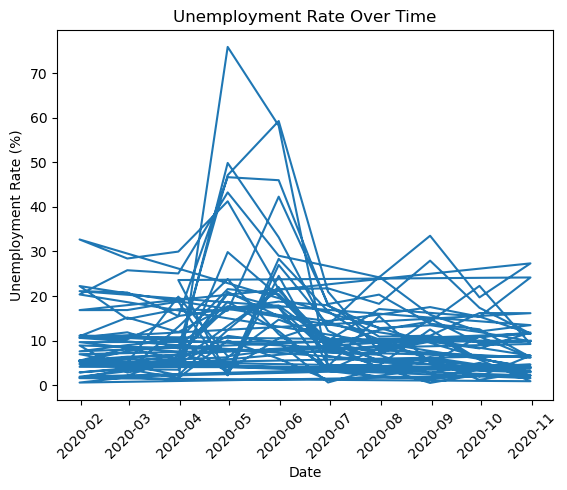

In [19]:
# 5. Exploratory Data Analysis (EDA)

plt.figure()
plt.plot(df['date'], df['estimated unemployment rate (%)'])
plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [21]:
covid_period = df[df['date'] >= '2020-01-01']


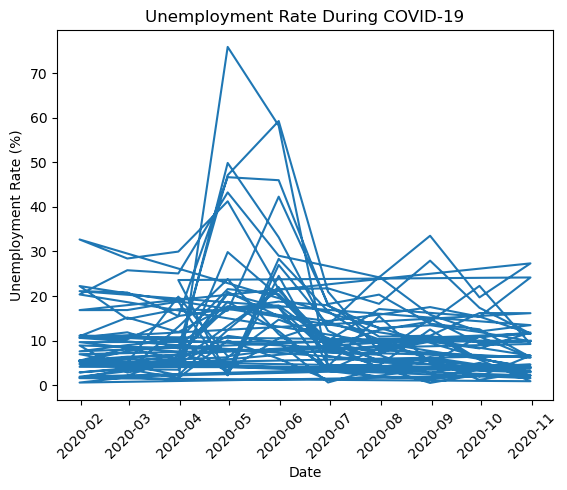

In [25]:
plt.figure()
plt.plot(covid_period['date'], covid_period['estimated unemployment rate (%)'])
plt.title("Unemployment Rate During COVID-19")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [26]:
df['month'] = df['date'].dt.month


In [28]:
monthly_avg = df.groupby('month')['estimated unemployment rate (%)'].mean()


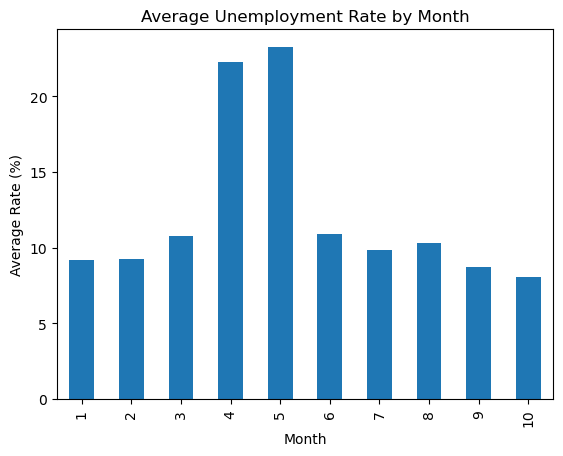

In [29]:
plt.figure()
monthly_avg.plot(kind='bar')
plt.title("Average Unemployment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Rate (%)")
plt.show()

In [31]:
df['year'] = df['date'].dt.year


In [33]:
yearly_avg = df.groupby('year')['estimated unemployment rate (%)'].mean()


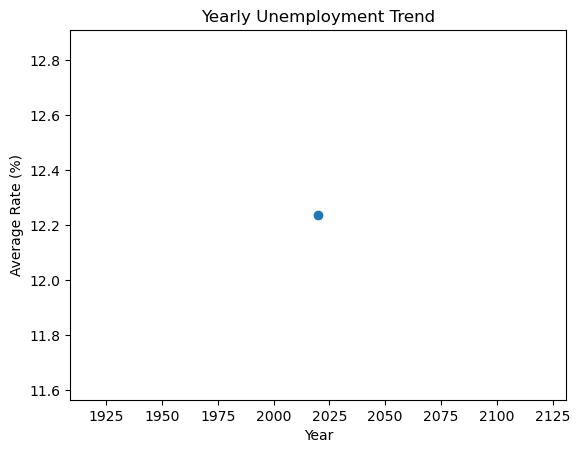

In [34]:
plt.figure()
yearly_avg.plot(marker='o')
plt.title("Yearly Unemployment Trend")
plt.xlabel("Year")
plt.ylabel("Average Rate (%)")
plt.show()

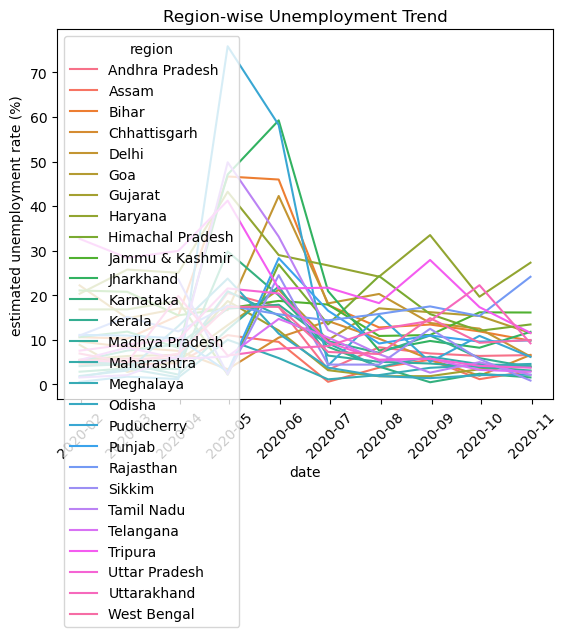

In [38]:
# 9. Region-wise Analysis (if dataset has region column)
if 'Region' in df.columns:
    plt.figure()
sns.lineplot(data=df, x='date', y='estimated unemployment rate (%)', hue='region')
plt.title("Region-wise Unemployment Trend")
plt.xticks(rotation=45)
plt.show()

In [36]:
# 10. Insights
print("\n📌 Insights:")
print("- Unemployment increased significantly during COVID-19 (2020).")
print("- Seasonal patterns may exist depending on region.")
print("- Trends vary across regions.")


📌 Insights:
- Unemployment increased significantly during COVID-19 (2020).
- Seasonal patterns may exist depending on region.
- Trends vary across regions.
